In [1]:
%load_ext autoreload
%autoreload 2

import os

os.environ["CUDA_VISIBLE_DEVICES"] = "3"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"


# Gradient Flow vs Anderson: Charged MVP Work and Wall Time

This notebook compares plain gradient flow and Anderson acceleration from the same initial parameters. The main work axis is the charged MVP-equivalent sample work reported by the flow histories.

In [2]:
from pathlib import Path
import itertools

from flax import nnx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd

from geometry.G_matrix import G_matrix
from functionals.linear_funcitonal_class import LinearPotential
from functionals.internal_functional_class import InternalPotential
from functionals.functional import Potential
from flows.anderson_acceleration import anderson_method
from flows.gradient_flow import run_gradient_flow
from parametric_model.parametric_model import ParametricModel


## Configuration

In [55]:
SAVE_FIGURES = False
FIG_DIR = Path("experiments/results/notebook_mvp_time")
if SAVE_FIGURES:
    FIG_DIR.mkdir(parents=True, exist_ok=True)

# Choose: "double banana", "gaussian", or "st".
case = "st"

dim = 50
seed = 1234
key = jax.random.PRNGKey(seed)

# Shared solver settings. Keep these identical for both methods.
solver = "cg"
solver_tol = 1e-4
solver_maxiter = 15
regularization = 1e-2

# Shared Monte Carlo settings. Increase for production-quality figures.
n_samples = 5_000
n_eval_samples = 1_000
max_iterations = 800


## Model and Potential

In [56]:
parametric_model = ParametricModel(
    parametric_map="node",
    rhs_model="mlp",
    architecture=[dim, 2, 64],
    activation_fn="tanh",
    time_dependent=True,
    solver="euler",
    dt0=0.1,
    ref_density="gaussian",
    scale_factor=1e-1,
)
graphdef, init_params = nnx.split(parametric_model)


In [57]:
from functools import partial
from jax.scipy.special import logsumexp
from functionals.functions import get_gaussian_potential, styblinski_tang_potential_fn

if case == "gaussian":
    mean = jnp.full((dim,), 2.0)
    sigma_inv = jnp.diag(jnp.array([1000.0, 10.0]))
    potential_fn = get_gaussian_potential(mean, sigma_inv)
    h = 1e-3
    m = 6
    beta = 1.25
    gamma_reg = 1e-5
    reg_method = "l2"
elif case == "double banana":
    def potential_fn_double_banana(x, shift):
        x = x - shift[..., :]
        x1 = x[..., 0]
        log_density = 2.0 * (jnp.linalg.norm(x, axis=-1) - 3.0) ** 2
        log_density -= logsumexp(
            jnp.stack([-2.0 * (x1 - 3.0) ** 2, -2.0 * (x1 + 3.0) ** 2], axis=-1),
            axis=-1,
        )
        return log_density

    potential_fn = partial(potential_fn_double_banana, shift=jnp.array([0.0, 0.0]))
    h = 5e-4
    m = 8
    beta = 1.8
    gamma_reg = 1e-5
    reg_method = "l2"
elif case == "st":
    potential_fn = partial(styblinski_tang_potential_fn, d=dim)
    h = 1e-3
    m = 8
    beta = 3.0
    gamma_reg = 1e-1
    reg_method = "l2"
else:
    raise ValueError(f"Unknown case: {case}")

linear_potential = LinearPotential(potential_fn=potential_fn, coeff=1.0)
internal_potential = InternalPotential(
    functional="entropy", coeff=1.0, method="hutchinson", prob_dim=dim
)
potential = Potential(linear=linear_potential, internal=internal_potential, interaction=None)

key, subkey = jax.random.split(key)
z_eval = jax.random.normal(subkey, (n_eval_samples, dim))


## Run Gradient Flow

In [58]:
init_params_gf = jax.tree.map(lambda x: x, init_params)
pm_gf = nnx.merge(graphdef, init_params_gf)
g_mat_gf = G_matrix(pm_gf)

history_gf = run_gradient_flow(
    pm_gf,
    z_eval,
    g_mat_gf,
    potential,
    N_samples=n_samples,
    h=h,
    solver=solver,
    max_iterations=max_iterations,
    solver_maxiter=solver_maxiter,
    tolerance=solver_tol,
    regularization=regularization,
    progress_every=max(1, max_iterations // 5),
    plot_intermediate=False,
    verbose=True,
    use_tqdm=True,
)
final_model_gf = history_gf["final_parametric_model"]


Gradient Flow Progress:  20%|██        | 162/800 [00:36<01:30,  7.04it/s, Energy=-881.789429, Linear=-792.968079, Internal=-88.821358, Interaction=0.000000]

Iter 160: Energy = -879.570679, Grad norm: 6.01e+01


Gradient Flow Progress:  40%|████      | 322/800 [00:59<01:09,  6.92it/s, Energy=-1260.587891, Linear=-1183.242554, Internal=-77.345383, Interaction=0.000000]

Iter 320: Energy = -1262.216553, Grad norm: 5.83e+01


Gradient Flow Progress:  60%|██████    | 482/800 [01:22<00:46,  6.84it/s, Energy=-1357.867920, Linear=-1287.380615, Internal=-70.487320, Interaction=0.000000]

Iter 480: Energy = -1357.220459, Grad norm: 5.88e+01


Gradient Flow Progress:  80%|████████  | 642/800 [01:44<00:21,  7.27it/s, Energy=-1401.710815, Linear=-1334.511108, Internal=-67.199661, Interaction=0.000000]

Iter 640: Energy = -1400.362549, Grad norm: 5.78e+01


Gradient Flow Progress: 100%|██████████| 800/800 [02:06<00:00,  6.33it/s, Energy=-1429.249023, Linear=-1364.307983, Internal=-64.940979, Interaction=0.000000]



=== Integration Complete ===
Total iterations:    800
Initial energy:      -394.489990
Final energy:        -1426.358154
Total decrease:      1031.868164
Reduction ratio:     3.6157
Final param norm:    42.211876


## Run Anderson Acceleration

In [59]:
init_params_aa = jax.tree.map(lambda x: x, init_params)
pm_aa = nnx.merge(graphdef, init_params_aa)
g_mat_aa = G_matrix(pm_aa)

final_params_aa, history_aa = anderson_method(
    parametric_model=pm_aa,
    batch_size=n_samples,
    test_data_set=z_eval,
    G_mat=g_mat_aa,
    potential=potential,
    initial_params=init_params_aa,
    n_iterations=max_iterations,
    step_size=h,
    memory_size=m,
    relaxation=beta,
    anderson_tol=solver_tol,
    solver=solver,
    solver_tol=solver_tol,
    solver_maxiter=solver_maxiter,
    regularization=regularization,
    convergence_tol=solver_tol,
    regularization_factor_gamma=gamma_reg,
    regularization_method_gamma=reg_method,
    ensure_descent=True,
    verbose=True,
)
final_model_aa = nnx.merge(graphdef, final_params_aa)


Starting Anderson-accelerated gradient flow
  n_iterations: 800
  step_size: 0.001
  memory_size: 8
  mixing_parameter: 3.0
------------------------------------------------------------
Iter    0 | Energy: -3.948355e+02 | Residual: 1.704731e-02 | 
Iter    1 | Energy: -3.959084e+02 | Residual: 1.768006e-02 | 
Iter    2 | Energy: -3.971257e+02 | Residual: 1.860869e-02 | 
Iter    3 | Energy: -3.986584e+02 | Residual: 1.993826e-02 | 
Iter    4 | Energy: -4.008497e+02 | Residual: 2.376792e-02 | 
Iter   10 | Energy: -4.457729e+02 | Residual: 5.583945e-02 | 
Iter   20 | Energy: -5.666577e+02 | Residual: 5.762296e-02 | 
Iter   30 | Energy: -6.506516e+02 | Residual: 4.789491e-02 | 
Iter   40 | Energy: -7.210184e+02 | Residual: 5.280314e-02 | 
Iter   50 | Energy: -8.181176e+02 | Residual: 6.124044e-02 | 
Iter   60 | Energy: -9.325736e+02 | Residual: 6.201065e-02 | 
Iter   70 | Energy: -1.037352e+03 | Residual: 5.752983e-02 | 
Iter   80 | Energy: -1.120055e+03 | Residual: 5.232359e-02 | 
Iter   90

## Build Comparison Tables

In [66]:
WORK_COLUMNS = [
    "grad_calls_cum",
    "solve_calls_cum",
    "direct_mvp_calls_cum",
    "grad_mvp_equiv_cum",
    "solve_mvp_equiv_cum",
    "direct_mvp_equiv_cum",
    "opt_mvp_equiv_cum",
    "grad_sample_work_cum",
    "solve_sample_work_cum",
    "direct_mvp_sample_work_cum",
    "opt_mvp_equiv_sample_work_cum",
]

def history_to_curve_df(method, energies, residuals, work_history):
    energies = list(energies)
    residuals = list(residuals)
    n = min(len(energies), len(residuals), len(work_history))
    rows = []
    for i in range(n):
        row = {
            "method": method,
            "outer_iter": i - 1,
            "energy": float(energies[i]),
            "riemann_grad_norm": float(residuals[i]),
        }
        row.update({k: work_history[i].get(k, float("nan")) for k in WORK_COLUMNS})
        rows.append(row)
    return pd.DataFrame(rows)

gf_curve = history_to_curve_df(
    "Gradient Flow",
    history_gf["energy_history"],
    history_gf["riemann_grad_norm_history"],
    history_gf["work_history"],
)
aa_curve = history_to_curve_df(
    "Anderson",
    history_aa["energies"],
    history_aa["riemann_grad_history"],
    history_aa["work_history"],
)
curve_df = pd.concat([gf_curve, aa_curve], ignore_index=True)

def summary_row(method, final_energy, final_metric, work_summary):
    return {
        "method": method,
        "final_energy": float(final_energy),
        "final_grad_or_residual_metric": float(final_metric),
        "elapsed_total_sec": float(work_summary.get("elapsed_total_sec", float("nan"))),
        "final_opt_mvp_equiv": float(work_summary.get("opt_mvp_equiv_cum", float("nan"))),
        "final_opt_mvp_equiv_sample_work": float(
            work_summary.get("opt_mvp_equiv_sample_work_cum", float("nan"))
        ),
        "final_grad_calls": int(work_summary.get("grad_calls_cum", 0)),
        "final_solve_calls": int(work_summary.get("solve_calls_cum", 0)),
        "final_direct_mvp_calls": int(work_summary.get("direct_mvp_calls_cum", 0)),
    }

summary_df = pd.DataFrame(
    [
        summary_row(
            "Gradient Flow",
            history_gf["energy_history"][-1],
            history_gf["riemann_grad_norm_history"][-1],
            history_gf["work_summary"],
        ),
        summary_row(
            "Anderson",
            history_aa["energies"][-1],
            history_aa["riemann_grad_history"][-1],
            history_aa["work_summary"],
        ),
    ]
)
summary_df


,method,final_energy,final_grad_or_residual_metric,elapsed_total_sec,final_opt_mvp_equiv,final_opt_mvp_equiv_sample_work,final_grad_calls,final_solve_calls,final_direct_mvp_calls
0,Gradient Flow,-1426.358154,19.586567,130.792882,12800.0,64000000.0,800,800,0
1,Anderson,-1555.906860,16.533462,224.862862,19979.0,99895000.0,801,801,7163


## Convergence vs Iteration

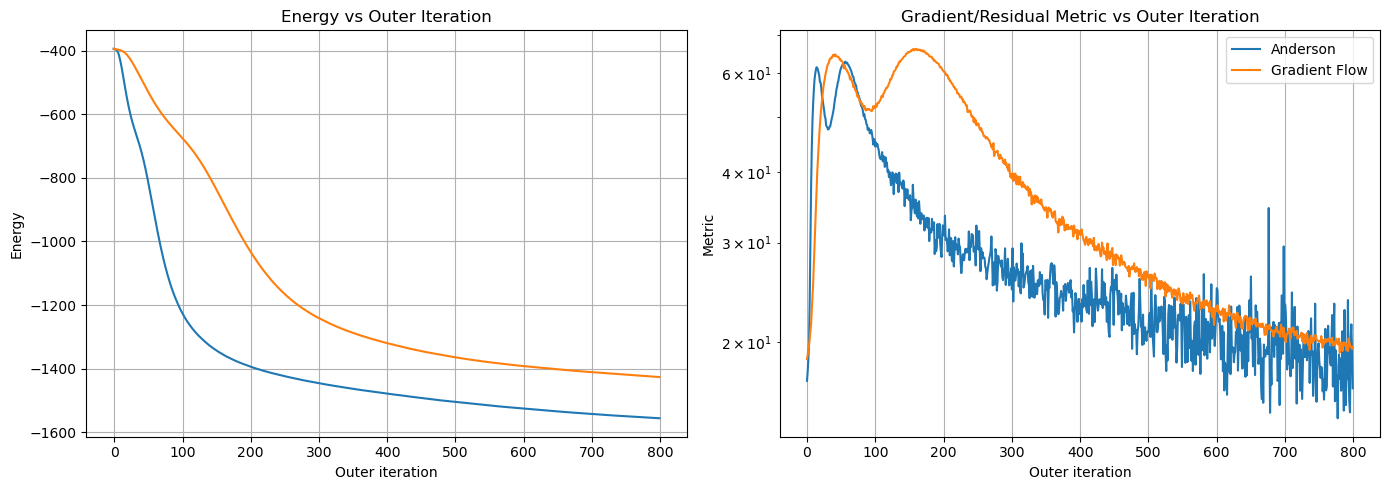

In [67]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for method, df in curve_df.groupby("method"):
    axs[0].plot(df["outer_iter"], df["energy"], label=method)
    axs[1].plot(df["outer_iter"], df["riemann_grad_norm"], label=method)

axs[0].set_title("Energy vs Outer Iteration")
axs[0].set_xlabel("Outer iteration")
axs[0].set_ylabel("Energy")
axs[0].grid(True)

axs[1].set_title("Gradient/Residual Metric vs Outer Iteration")
axs[1].set_xlabel("Outer iteration")
axs[1].set_ylabel("Metric")
axs[1].set_yscale("log")
axs[1].grid(True)
axs[1].legend()

fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIG_DIR / f"{case}_convergence_vs_iteration.png", dpi=150)


## Convergence vs Charged MVP-Equivalent Sample Work

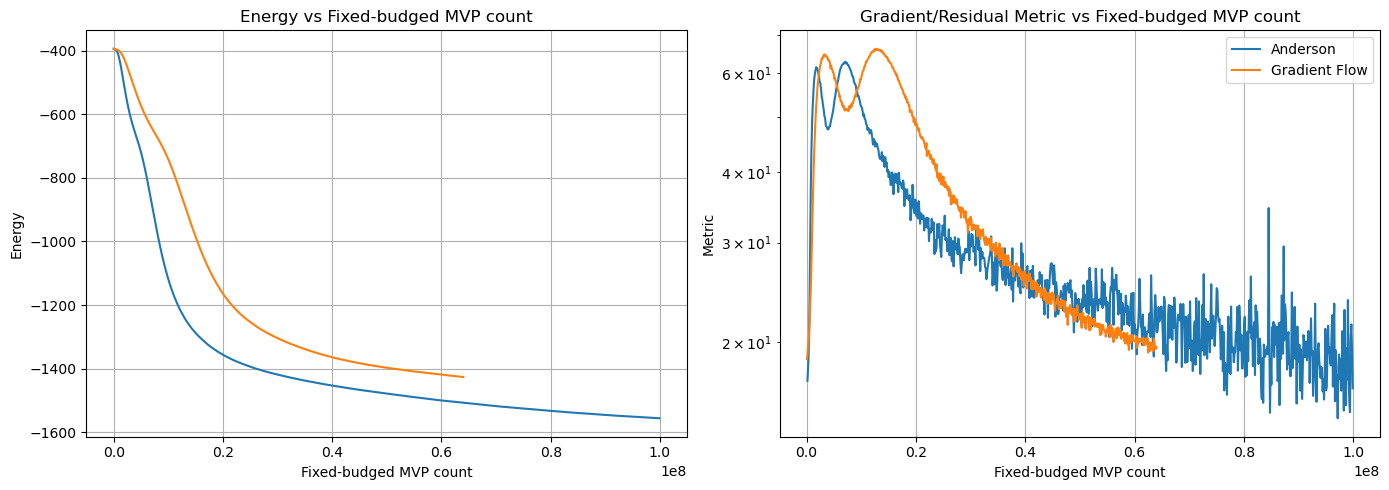

In [68]:
work_col = "opt_mvp_equiv_sample_work_cum"

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for method, df in curve_df.groupby("method"):
    axs[0].plot(df[work_col], df["energy"], label=method)
    axs[1].plot(df[work_col], df["riemann_grad_norm"], label=method)

axs[0].set_title("Energy vs Fixed-budged MVP count")
axs[0].set_xlabel("Fixed-budged MVP count")
axs[0].set_ylabel("Energy")
axs[0].grid(True)

axs[1].set_title("Gradient/Residual Metric vs Fixed-budged MVP count")
axs[1].set_xlabel("Fixed-budged MVP count")
axs[1].set_ylabel("Metric")
axs[1].set_yscale("log")
axs[1].grid(True)
axs[1].legend()

fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIG_DIR / f"{case}_convergence_vs_charged_work.png", dpi=150)


## Resource Summary

,method,final_energy,final_grad_or_residual_metric,elapsed_total_sec,final_opt_mvp_equiv,final_opt_mvp_equiv_sample_work,final_grad_calls,final_solve_calls,final_direct_mvp_calls
0,Gradient Flow,-1426.358154,19.586567,130.792882,12800.0,64000000.0,800,800,0
1,Anderson,-1555.906860,16.533462,224.862862,19979.0,99895000.0,801,801,7163


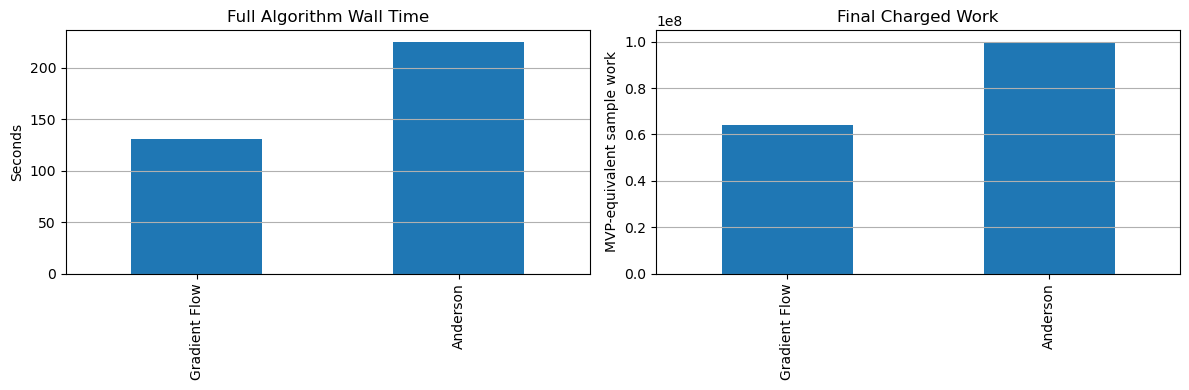

In [69]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

summary_df.plot.bar(x="method", y="elapsed_total_sec", ax=axs[0], legend=False)
axs[0].set_title("Full Algorithm Wall Time")
axs[0].set_ylabel("Seconds")
axs[0].set_xlabel("")
axs[0].grid(axis="y")

summary_df.plot.bar(x="method", y="final_opt_mvp_equiv_sample_work", ax=axs[1], legend=False)
axs[1].set_title("Final Charged Work")
axs[1].set_ylabel("MVP-equivalent sample work")
axs[1].set_xlabel("")
axs[1].grid(axis="y")

fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIG_DIR / f"{case}_resource_summary.png", dpi=150)

summary_df


## Normalized Energy Progress vs Charged Work

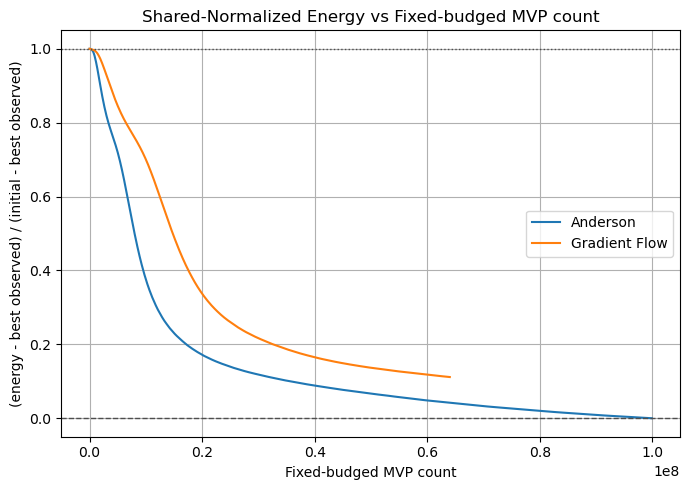

In [70]:
norm_df = curve_df.copy()

initial_values = norm_df.loc[norm_df["outer_iter"] == -1, "energy"].to_numpy()
assert len(initial_values) > 0, "Expected an initial zero-work row at outer_iter == -1."
assert abs(initial_values - initial_values[0]).max() < 1e-6, initial_values

E_initial = float(initial_values[0])
E_best = float(norm_df["energy"].min())
denom = E_initial - E_best

norm_df["energy_norm_shared"] = (
    (norm_df["energy"] - E_best) / denom if abs(denom) > 1e-12 else jnp.nan
)

fig, ax = plt.subplots(figsize=(7, 5))
for method, df in norm_df.groupby("method"):
    ax.plot(df[work_col], df["energy_norm_shared"], label=method)

ax.axhline(0.0, color="0.3", linewidth=1, linestyle="--")
ax.axhline(1.0, color="0.3", linewidth=1, linestyle=":")
ax.set_title("Shared-Normalized Energy vs Fixed-budged MVP count")
ax.set_xlabel("Fixed-budged MVP count")
ax.set_ylabel("(energy - best observed) / (initial - best observed)")
ax.grid(True)
ax.legend()
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIG_DIR / f"{case}_normalized_energy_vs_charged_work.png", dpi=150)


## Final Sample Comparison

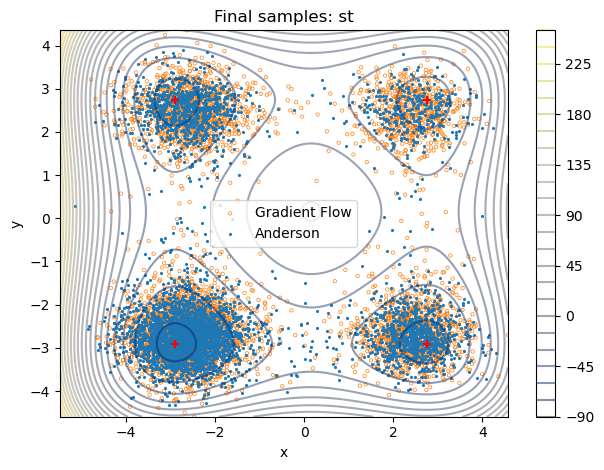

In [71]:
key, subkey = jax.random.split(key)
z_plot = jax.random.normal(subkey, shape=(5_000, dim))

sample_gf = final_model_gf(z_plot)
sample_aa = final_model_aa(z_plot)

joint_sample = jnp.concatenate((sample_gf, sample_aa), axis=0)
left = jnp.min(joint_sample, axis=0)
right = jnp.max(joint_sample, axis=0)
bds = jnp.stack((left, right)).T

ax = potential.linear.plot_function(x_bds=bds[0], y_bds=bds[1], fill=False, levels=30)
fig = ax.get_figure()
ax.scatter(*sample_gf[:, :2].T, label="Gradient Flow", s=6.0, marker="o", facecolors="none", edgecolors="C1", linewidths=0.5)
ax.scatter(*sample_aa[:, :2].T, label="Anderson", s=2.0, marker="*", color="C0")

if case == "st":
    p_st = jnp.array([1.0, 0.0, -16.0, 5.0, 0.0])
    dp_st = jnp.polyder(p_st)
    extrema = jnp.roots(dp_st).real
    mins_st = jnp.sort(extrema)[jnp.array([0, -1])]
    for x, y in itertools.product(mins_st, mins_st):
        ax.scatter(x, y, marker="+", color="r")

ax.legend()
ax.set_title(f"Final samples: {case}")
fig.tight_layout()
if SAVE_FIGURES:
    fig.savefig(FIG_DIR / f"{case}_final_samples.png", dpi=150)
